In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [2]:
df = pd.read_csv('/content/creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
X = df.drop('Class',axis =1)
y = df['Class']

In [11]:
X.shape, y.shape

((284807, 30), (284807,))

In [16]:
scalar = StandardScaler()
X = scalar.fit_transform(X)

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
X_ok = pca.fit_transform(X)

In [18]:
X_ok.shape

(284807, 10)

In [45]:
# And now to visualize it to decompose So conver it into smaller components lets say 2

pca_smalled = PCA(n_components=2)
# Transform X_ok into 2 principal components
z_components = pca_smalled.fit_transform(X_ok)

# Create a DataFrame from the 2 PCA components with appropriate column names
z = pd.DataFrame(data = z_components, columns = ['PCA1', 'PCA2'])

# Add the 'Class' column (original labels) to the DataFrame
z['Class'] = y

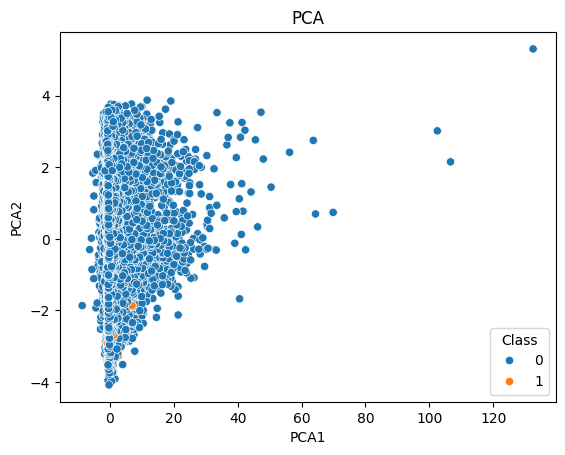

In [46]:
sns.scatterplot(x='PCA1', y='PCA2', hue='Class', data=z)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA')
plt.show()

In [31]:
means = KMeans(n_clusters=2,random_state=42)
means.fit(X_ok)

KMeans(n_clusters=2, random_state=42)

In [32]:
clusters = means.labels_

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [38]:
clusters = means.labels_
pca_column_names = [f'PCA_{i}' for i in range(X_ok.shape[1])]
all_column_names = pca_column_names + ['cluster']
cluster_df = pd.DataFrame(np.hstack((X_ok, clusters.reshape(-1,1))), columns=all_column_names)

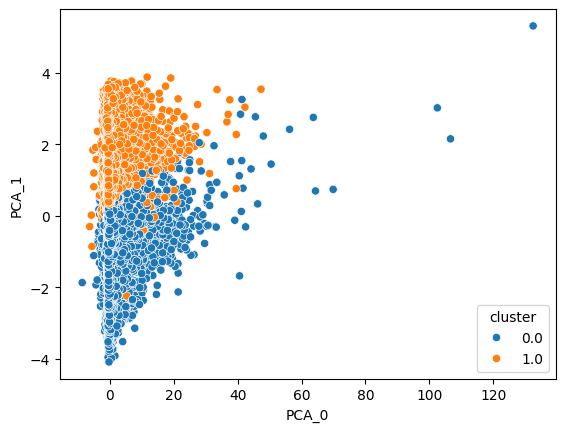

In [41]:
# K Means classes
sns.scatterplot(x='PCA_0', y='PCA_1', hue='cluster', data=cluster_df)
plt.show()